In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers


# -------------------------------------------------
# Dados de treino
# Queremos:
# saída 1 apenas em (0.5, 0.5)
# saída 0 nos demais pontos
# -------------------------------------------------
AX = np.array([
    [0.5, 0.5],
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.5, 0.0],
    [0.0, 0.5],
    [0.5, 1.0],
    [1.0, 0.5]
], dtype=np.float32)

AY = np.array([
    [1.0],
    [0.0],
    [0.0],
    [0.0],
    [0.0],
    [0.0],
    [0.0],
    [0.0],
    [0.0]
], dtype=np.float32)

print("AX:")
print(AX)
print("AY:")
print(AY)

AX:
[[0.5 0.5]
 [0.  0. ]
 [0.  1. ]
 [1.  0. ]
 [1.  1. ]
 [0.5 0. ]
 [0.  0.5]
 [0.5 1. ]
 [1.  0.5]]
AY:
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [15]:

# -------------------------------------------------
# Rede com 3 neurônios escondidos
# -------------------------------------------------
model = Sequential()
model.add(Dense(3, activation='sigmoid', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

sgd = optimizers.SGD(learning_rate=0.2)
model.compile(optimizer=sgd, loss='mse')

# Treinamento
history = model.fit(AX, AY, epochs=1000, batch_size=2, verbose=0)


# -------------------------------------------------
# Parâmetros treinados
# -------------------------------------------------
print("\nParâmetros treinados:")
for layer in model.layers:
    weights = layer.get_weights()
    if weights:
        print(f"\nLayer: {layer.name}")
        print("Weights:")
        print(weights[0])
        print("Biases:")
        print(weights[1])


Parâmetros treinados:

Layer: dense_18
Weights:
[[ 0.6079415  -0.01307993 -1.0308717 ]
 [-0.00761816 -0.17228349 -1.0694492 ]]
Biases:
[-0.12406675  0.34699267 -0.08962457]

Layer: dense_19
Weights:
[[ 0.09434538]
 [-1.6130829 ]
 [ 0.0191155 ]]
Biases:
[-1.1319118]


In [16]:
# -------------------------------------------------
# Teste nos pontos de treino
# -------------------------------------------------
QP = model.predict(AX, verbose=0)

print("\nSaídas da rede nos pontos de treino:")
for x, y_true, y_pred in zip(AX, AY, QP):
    print(f"Entrada: {x}, desejado: {y_true[0]:.1f}, obtido: {y_pred[0]:.4f}")




Saídas da rede nos pontos de treino:
Entrada: [0.5 0.5], desejado: 1.0, obtido: 0.1208
Entrada: [0. 0.], desejado: 0.0, obtido: 0.1167
Entrada: [0. 1.], desejado: 0.0, obtido: 0.1235
Entrada: [1. 0.], desejado: 0.0, obtido: 0.1183
Entrada: [1. 1.], desejado: 0.0, obtido: 0.1253
Entrada: [0.5 0. ], desejado: 0.0, obtido: 0.1175
Entrada: [0.  0.5], desejado: 0.0, obtido: 0.1200
Entrada: [0.5 1. ], desejado: 0.0, obtido: 0.1243
Entrada: [1.  0.5], desejado: 0.0, obtido: 0.1217


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


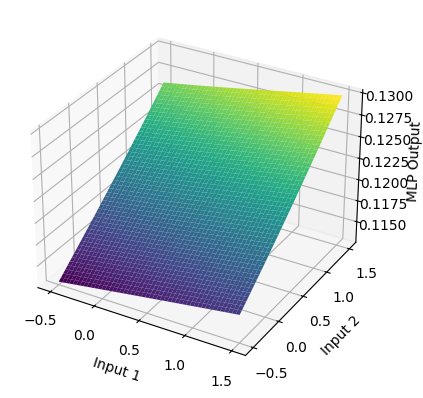

In [17]:
# Generate data for 3D plot
x1 = np.linspace(-0.5, 1.5, 50)
x2 = np.linspace(-0.5, 1.5, 50)
x1_grid, x2_grid = np.meshgrid(x1, x2)
QX_3d = np.hstack((x1_grid.reshape(-1, 1), x2_grid.reshape(-1, 1)))
QP_3d = model.predict(QX_3d)

# Plot the 3D surface
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x1_grid, x2_grid, QP_3d.reshape(x1_grid.shape), cmap='viridis')
ax.set_xlabel('Input 1')
ax.set_ylabel('Input 2')
ax.set_zlabel('MLP Output')
plt.show()

a) Não, com a estrutura simples do programa 1a e apenas 2 neurônios escondidos isso não é suficiente.
Mesmo com 3 neurônios, em geral ainda não é o bastante para formar uma região fechada pequena ao redor de (0.5,0.5).

A rede encontrou um compromisso ruim, minimizando o erro sem conseguir criar o pico no centro.

In [22]:
model = Sequential()
model.add(Dense(4, activation='sigmoid', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

opt = optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss='binary_crossentropy')

sample_weight = np.array([8, 1, 1, 1, 1, 1, 1, 1, 1], dtype=np.float32)

model.fit(
    AX, AY,
    epochs=10000,
    batch_size=1,
    verbose=0,
    sample_weight=sample_weight
)

QP = model.predict(AX, verbose=0)

print("Saídas da rede nos pontos de treino:")
for x, yd, yp in zip(AX, AY, QP):
    print(f"Entrada: {x}, desejado: {yd[0]:.1f}, obtido: {yp[0]:.4f}")

Saídas da rede nos pontos de treino:
Entrada: [0.5 0.5], desejado: 1.0, obtido: 1.0000
Entrada: [0. 0.], desejado: 0.0, obtido: 0.0000
Entrada: [0. 1.], desejado: 0.0, obtido: 0.0000
Entrada: [1. 0.], desejado: 0.0, obtido: 0.0000
Entrada: [1. 1.], desejado: 0.0, obtido: 0.0000
Entrada: [0.5 0. ], desejado: 0.0, obtido: 0.0000
Entrada: [0.  0.5], desejado: 0.0, obtido: 0.0000
Entrada: [0.5 1. ], desejado: 0.0, obtido: 0.0000
Entrada: [1.  0.5], desejado: 0.0, obtido: 0.0000
